# Compile experiment results into a dictionary

In [1]:
from tabpfn_project.paths import EXPERIMENTS_DATA_DIR, RESULTS_DIR

metadata_dir = EXPERIMENTS_DATA_DIR / "experiment_context_sizes" / "metadata"
tabpfn_preds_dir = EXPERIMENTS_DATA_DIR / "experiment_context_sizes" / "tabpfn_preds_full"
results_dir = RESULTS_DIR / "experiment_context_sizes"
results_dir.mkdir(parents=True, exist_ok=True)

In [2]:
import pathlib
import pickle

class WindowsPathUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if name == 'PosixPath' and 'pathlib' in module:
            return pathlib.WindowsPath
        return super().find_class(module, name)

In [3]:
import platform
from tabpfn_project.paths import RESULTS_DIR 

def fetch_save_dict(metadata_dir: pathlib.Path):
    experiment_results_dict = {}

    for fpath in metadata_dir.glob('*.pkl'):
        
        with open(fpath, 'rb') as f:
            # Use our custom Unpickler on Windows, otherwise standard pickle
            if platform.system() == 'Windows':
                results_dict = WindowsPathUnpickler(f).load()
            else:
                results_dict = pickle.load(f)

        context_size = results_dict['context_size']
        
        if context_size == 2**13 + 2000 or context_size == 2**13 + 4000:
            continue  # Skip these context sizes 
        
        model_name   = results_dict['model_name']
        scenario     = results_dict['scenario']
        fold         = results_dict['fold']
        seed_context = results_dict['seed_context']

        # Construct the nested dictionary
        experiment_results_dict \
            .setdefault(model_name, {}) \
            .setdefault(scenario, {}) \
            .setdefault(context_size, {}) \
            .setdefault(fold, {})[seed_context] = results_dict
    
    save_file_path = results_dir / "experiment_results_dict.pkl"
    
    with open(save_file_path, 'wb') as f:
        pickle.dump(experiment_results_dict, f)
        
    print(f"Saved to {save_file_path}")

# Run it!
# fetch_save_dict(metadata_dir)

In [4]:
load_path = results_dir / "experiment_results_dict.pkl"
with open(load_path, 'rb') as f:
    experiment_results_dict = pickle.load(f)
print("Loaded successfully.")
print("Models:", list(experiment_results_dict.keys()))

Loaded successfully.
Models: ['distnet', 'tabpfn']


# Helpers

In [5]:
from tabpfn_project.globals import RANDOM_STATE
from tabpfn_project.paths import DATA_DIR

In [6]:
import numpy as np
from tabpfn_project.helper import data_source_release, load_data
from sklearn.model_selection import KFold

def load_y_test(scenario_name, fold_idx):
    sc_dict = data_source_release.get_sc_dict()
    data_dir = DATA_DIR

    runtimes, _, _ = load_data.get_data(
        scenario=scenario_name, 
        sc_dict=sc_dict,
        retrieve=sc_dict[scenario_name]['use']
    )
        
    runtimes = np.asarray(runtimes)

    # Get CV splits
    kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
    splits = list(kf.split(np.arange(runtimes.shape[0])))
    _, test_idx = splits[fold_idx]  # process the specified fold

    #------------------------------------#
    y_test = runtimes[test_idx]
    return y_test

def load_tabpfn_preds(scenario_name, fold_idx, context_size, context_seed, seed_features, seed_samples_per_instance, feature_drop_rate, target_scale, subsample_method, num_samples_per_instance, use_cpu):
    fname = (
        f"tabpfn_{scenario_name}_{fold_idx}_{context_seed}_{seed_features}_{seed_samples_per_instance}_{feature_drop_rate}_"
                         f"{context_size}_{target_scale}_{subsample_method}_{num_samples_per_instance}_{'cpu' if use_cpu else 'gpu'}_test_preds.pkl"
    )
    fpath = tabpfn_preds_dir / fname
    with open(fpath, 'rb') as f:
        if platform.system() == 'Windows':
            preds = WindowsPathUnpickler(f).load()
        else:
            preds = pickle.load(f)
            
    return preds
    

# Calculate metrics of interest and store results

In [7]:
from tabpfn_project.globals import DISTNET_SCENARIOS, MODELS, DISTNET_CONTEXT_SIZES, DISTNET_CONTEXT_SEEDS, N_FOLDS, N_GRID_POINTS

In [8]:
import torch

from tabpfn_project.helper.distnet_helpers import (
    calculate_all_distribution_metrics_distnet_logspace,
)
from tabpfn_project.helper.pfn_helpers import calculate_distribution_metrics_logspace_tabpfn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def calculate_all_metrics(tabpfn_context_size_results, distnet_context_size_results):
    total_experiments = len(DISTNET_SCENARIOS) * len(MODELS) * len(DISTNET_CONTEXT_SIZES) * len(range(N_FOLDS)) * len(DISTNET_CONTEXT_SEEDS)
    current_experiment = 0
    for scenario in DISTNET_SCENARIOS:
        for model_name in MODELS:
            for context_size in DISTNET_CONTEXT_SIZES:
                for fold in range(N_FOLDS):
                    y_test = load_y_test(scenario, fold)
                    for context_seed in DISTNET_CONTEXT_SEEDS:
                        case_dict = experiment_results_dict[model_name][scenario][context_size][fold][context_seed]

                        if model_name == 'tabpfn':
                            tabpfn_preds = load_tabpfn_preds(scenario, fold, context_size, context_seed, case_dict['seed_features'],
                                                            case_dict['seed_samples_per_instance'], case_dict['feature_drop_rate'],
                                                            case_dict['target_scale'], case_dict['subsample_method'],
                                                            case_dict['num_samples_per_instance'], case_dict['use_cpu'])
                            metrics_summary, instance_summary = calculate_distribution_metrics_logspace_tabpfn(y_test, tabpfn_preds, device=device, target_scale=case_dict['target_scale'], N_grid_points=N_GRID_POINTS)
                            tabpfn_context_size_results.append({
                                "scenario": scenario, "model": model_name, "context_size": context_size,
                                "fold": fold, "context_seed": context_seed,
                                "metrics_summ0ary": metrics_summary, "instance_summary": instance_summary
                            })

                        elif model_name == 'distnet':
                            metrics_summary, instance_summary = calculate_all_distribution_metrics_distnet_logspace(y_test, case_dict['test_preds'], device=device, y_scaler=case_dict['y_scale'], N_grid_points=N_GRID_POINTS)
                            distnet_context_size_results.append({
                                "scenario": scenario, "model": model_name, "context_size": context_size,
                                "fold": fold, "context_seed": context_seed,
                                "metrics_summary": metrics_summary, "instance_summary": instance_summary
                            })
                        
                        current_experiment += 1
                        print(f"✅Completed experiment {current_experiment}/{total_experiments}")



tabpfn_context_size_results = []
distnet_context_size_results = []
calculate_all_metrics(tabpfn_context_size_results, distnet_context_size_results)

Train data loaded
Test data loaded
(2000, 113) (2000, 100)
Discarding 0 (2000) instances because of CRASHED
Discarding 0 (2000) instances because of TIMEOUT
Discarding 0 (2000) instances because not stated TIMEOUTS
Discarding 0 (2000) instances because of constant features
Discarding 0 (2000) instances because of UNSAT
Imputed 149 values with median
✅Completed experiment 1/9100
✅Completed experiment 2/9100
✅Completed experiment 3/9100
✅Completed experiment 4/9100
✅Completed experiment 5/9100
Train data loaded
Test data loaded
(2000, 113) (2000, 100)
Discarding 0 (2000) instances because of CRASHED
Discarding 0 (2000) instances because of TIMEOUT
Discarding 0 (2000) instances because not stated TIMEOUTS
Discarding 0 (2000) instances because of constant features
Discarding 0 (2000) instances because of UNSAT
Imputed 149 values with median
✅Completed experiment 6/9100
✅Completed experiment 7/9100
✅Completed experiment 8/9100
✅Completed experiment 9/9100
✅Completed experiment 10/9100
Train

In [9]:
tabpfn_save_path = results_dir / "tabpfn_context_size_results.pkl"
with open(tabpfn_save_path, 'wb') as f:
    pickle.dump(tabpfn_context_size_results, f)
print(f"Saved TabPFN results ({len(tabpfn_context_size_results)} entries) to {tabpfn_save_path}")

distnet_save_path = results_dir / "distnet_context_size_results.pkl"
with open(distnet_save_path, 'wb') as f:
    pickle.dump(distnet_context_size_results, f)
print(f"Saved DistNet results ({len(distnet_context_size_results)} entries) to {distnet_save_path}")

Saved TabPFN results (4550 entries) to C:\Users\ihagv\Desktop\Study Project UFR\master_project\results\experiment_context_sizes\tabpfn_context_size_results.pkl
Saved DistNet results (4550 entries) to C:\Users\ihagv\Desktop\Study Project UFR\master_project\results\experiment_context_sizes\distnet_context_size_results.pkl


### Visualization

In [13]:

import pickle
from collections import defaultdict

import numpy as np

results_dir = RESULTS_DIR / "experiment_context_sizes"

with open(f"{results_dir}/tabpfn_context_size_results.pkl", "rb") as f:
    tabpfn_results = pickle.load(f)

with open(f"{results_dir}/distnet_context_size_results.pkl", "rb") as f:
    distnet_results = pickle.load(f)

all_results = tabpfn_results + distnet_results

METRICS = ["NLLH", "CRPS", "Wasserstein", "KS"]

# Aggregate: for each (model, scenario, context_size) concatenate all per-instance arrays
# across all folds and seeds, then compute mean and std.
agg = defaultdict(lambda: defaultdict(list))
# agg[(model, scenario, context_size)][metric] -> list of per-instance values

for entry in all_results:
    model        = entry["model"]
    scenario     = entry["scenario"]
    context_size = entry["context_size"]
    inst_summ    = entry["instance_summary"]
    key = (model, scenario, context_size)
    for metric in METRICS:
        vals = inst_summ[metric]
        # handle both torch tensors and numpy arrays
        if hasattr(vals, "cpu"):
            vals = vals.cpu().numpy()
        vals = np.asarray(vals).ravel()
        agg[key][metric].append(vals)

# Compute final mean / std per (model, scenario, context_size, metric)
plot_data = {}
for key, metric_dict in agg.items():
    plot_data[key] = {}
    for metric, arrays in metric_dict.items():
        combined = np.concatenate(arrays)
        plot_data[key][metric] = (combined.mean(), combined.std(), len(combined))

# Collect unique scenarios and context_sizes (sorted)
scenarios     = sorted({key[1] for key in plot_data})
context_sizes = sorted({key[2] for key in plot_data})
models        = ["tabpfn", "distnet"]

print(f"Scenarios: {scenarios}")
print(f"Context sizes: {context_sizes}")
print(f"Models: {models}")
print(f"Total aggregated entries: {len(plot_data)}")


Scenarios: ['clasp_factoring', 'lpg-zeno', 'saps-CVVAR', 'spear_qcp', 'spear_swgcp', 'yalsat_qcp', 'yalsat_swgcp']
Context sizes: [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072]
Models: ['tabpfn', 'distnet']
Total aggregated entries: 182


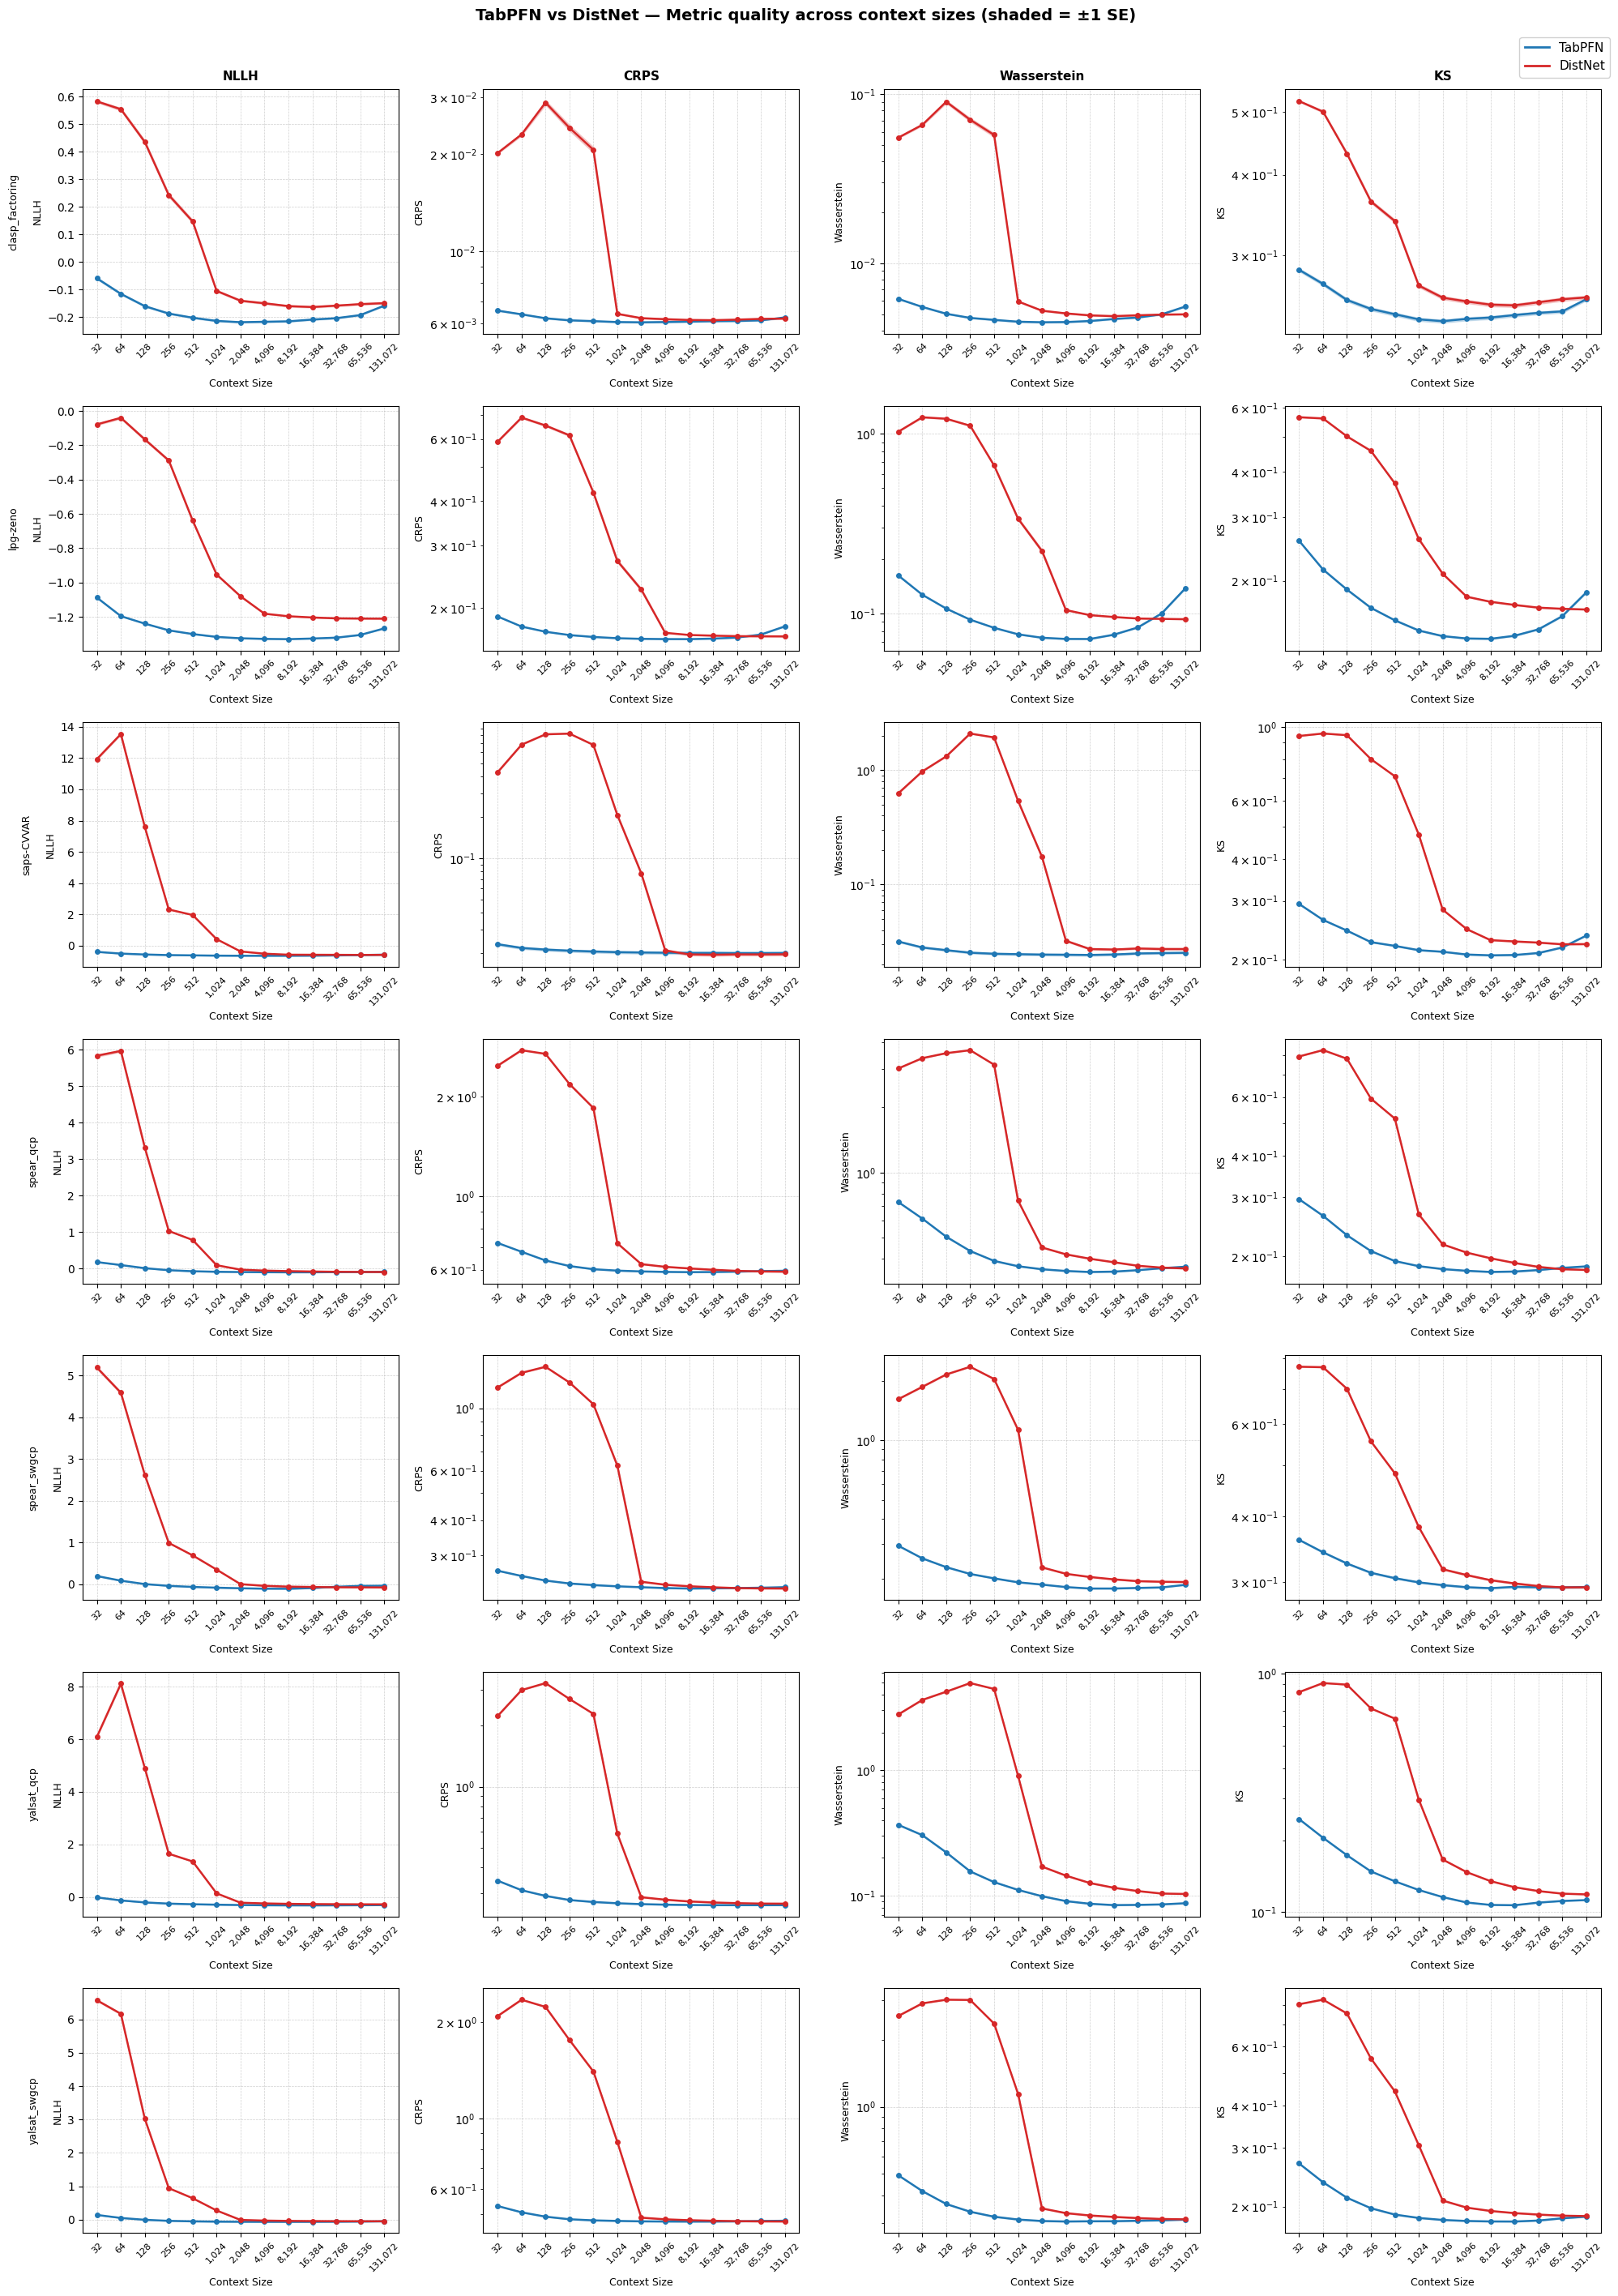

In [15]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

MODEL_COLORS  = {"tabpfn": "#1f77b4", "distnet": "#d62728"}
MODEL_LABELS  = {"tabpfn": "TabPFN",  "distnet": "DistNet"}
METRIC_LABELS = {"NLLH": "NLLH", "CRPS": "CRPS", "Wasserstein": "Wasserstein", "KS": "KS"}

n_rows = len(scenarios)
n_cols = len(METRICS)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False,
)

for row_idx, scenario in enumerate(scenarios):
    for col_idx, metric in enumerate(METRICS):
        ax = axes[row_idx][col_idx]

        for model in models:
            xs, means, stds = [], [], []
            for cs in context_sizes:
                key = (model, scenario, cs)
                if key in plot_data and metric in plot_data[key]:
                    m, s, n = plot_data[key][metric]
                    xs.append(cs)
                    means.append(m)
                    stds.append(s / np.sqrt(n))

            if not xs:
                continue

            xs    = np.array(xs,    dtype=float)
            means = np.array(means, dtype=float)
            stds  = np.array(stds,  dtype=float)

            color = MODEL_COLORS[model]
            ax.plot(xs, means, marker="o", markersize=4, linewidth=1.8,
                    color=color, label=MODEL_LABELS[model])
            ax.fill_between(xs, means - stds, means + stds,
                            alpha=0.20, color=color)

        ax.set_xscale("log", base=2)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
        ax.xaxis.set_minor_formatter(ticker.NullFormatter())
        ax.set_xticks(context_sizes)
        ax.tick_params(axis="x", labelrotation=45, labelsize=8)

        if metric in ("CRPS", "Wasserstein", "KS"):
            ax.set_yscale("log")

        ax.set_xlabel("Context Size", fontsize=9)
        ax.set_ylabel(METRIC_LABELS[metric], fontsize=9)

        if row_idx == 0:
            ax.set_title(METRIC_LABELS[metric], fontsize=11, fontweight="bold", pad=8)

        if col_idx == 0:
            ax.set_ylabel(
                f"{scenario}\n\n{METRIC_LABELS[metric]}",
                fontsize=9,
            )

        ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.6)

# Shared legend
handles = [
    matplotlib.lines.Line2D([0], [0], color=MODEL_COLORS[m], linewidth=2, label=MODEL_LABELS[m])
    for m in models
]
fig.legend(handles=handles, loc="upper right", fontsize=11, framealpha=0.9,
           bbox_to_anchor=(1.0, 1.0))

plt.suptitle(
    "TabPFN vs DistNet — Metric quality across context sizes (shaded = ±1 SE)",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()


In [19]:
import os

import numpy as np
import pandas as pd

rows = []
for scenario in scenarios:
    for cs in context_sizes:
        row = {"Scenario": scenario, "Context Size": cs}
        for model in models:
            key = (model, scenario, cs)
            if key in plot_data:
                for metric in METRICS:
                    m, s, n = plot_data[key][metric]
                    row[f"{MODEL_LABELS[model]} {metric} mean"] = round(float(m), 4)
                    row[f"{MODEL_LABELS[model]} {metric} SE"]   = round(float(s / np.sqrt(n)), 4)
            else:
                for metric in METRICS:
                    row[f"{MODEL_LABELS[model]} {metric} mean"] = None
                    row[f"{MODEL_LABELS[model]} {metric} SE"]   = None
        rows.append(row)

df = pd.DataFrame(rows)

# Build a multi-level column index: (metric, model stat) for display
col_order = ["Scenario", "Context Size"]
for metric in METRICS:
    for model in models:
        col_order.append(f"{MODEL_LABELS[model]} {metric} mean")
        col_order.append(f"{MODEL_LABELS[model]} {metric} SE")
df = df[col_order]

# Pretty display with multi-level header
metric_cols = {}
for metric in METRICS:
    for model in models:
        metric_cols[f"{MODEL_LABELS[model]} {metric} mean"] = (metric, MODEL_LABELS[model], "mean")
        metric_cols[f"{MODEL_LABELS[model]} {metric} SE"]   = (metric, MODEL_LABELS[model], "SE")

tuples = [("", "", col) if col in ("Scenario", "Context Size")
          else metric_cols[col]
          for col in df.columns]
df.columns = pd.MultiIndex.from_tuples(tuples)

pd.set_option("display.max_rows",    None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width",       None)
pd.set_option("display.float_format", "{:.4f}".format)

# Save to CSV (multi-level header flattened to "Metric_Model_stat")
csv_path =  RESULTS_DIR / "experiment_context_sizes" / "context_size_metrics_table.csv"
df_csv = df.copy()
df_csv.columns = [
    "_".join(filter(None, col)).strip("_") if isinstance(col, tuple) else col
    for col in df_csv.columns
]
df_csv.to_csv(csv_path, index=False)
print(f"Table saved to {csv_path}")

df


Table saved to C:\Users\ihagv\Desktop\Study Project UFR\master_project\results\experiment_context_sizes\context_size_metrics_table.csv


NLLH                         CRPS         \
                                  TabPFN        DistNet        TabPFN          
           Scenario Context Size    mean     SE    mean     SE   mean     SE   
0   clasp_factoring           32 -0.0589 0.0035  0.5833 0.0037 0.0066 0.0000   
1   clasp_factoring           64 -0.1152 0.0030  0.5549 0.0049 0.0064 0.0000   
2   clasp_factoring          128 -0.1598 0.0026  0.4362 0.0061 0.0062 0.0000   
3   clasp_factoring          256 -0.1867 0.0024  0.2434 0.0063 0.0061 0.0000   
4   clasp_factoring          512 -0.2019 0.0023  0.1476 0.0058 0.0061 0.0000   
5   clasp_factoring         1024 -0.2134 0.0022 -0.1045 0.0031 0.0061 0.0000   
6   clasp_factoring         2048 -0.2181 0.0021 -0.1402 0.0029 0.0060 0.0000   
7   clasp_factoring         4096 -0.2165 0.0022 -0.1495 0.0029 0.0061 0.0000   
8   clasp_factoring         8192 -0.2150 0.0021 -0.1597 0.0026 0.0061 0.0000   
9   clasp_factoring        16384 -0.2085 0.0020 -0.1630 0.0026 0.0061 0.0000   
10  clasp_factoring        32768 -0.2036 0.0020 -0.1580 0.0026 0.0061 0.0000   
11  clasp_factoring        65536 -0.1923 0.0019 -0.1525 0.0027 0.0061 0.0000   
12  clasp_factoring       131072 -0.1582 0.0017 -0.1490 0.0028 0.0063 0.0000   
13         lpg-zeno           32 -1.0878 0.0022 -0.0780 0.0044 0.1890 0.0003   
14         lpg-zeno           64 -1.1960 0.0014 -0.0397 0.0053 0.1770 0.0002   
15         lpg-zeno          128 -1.2396 0.0013 -0.1654 0.0059 0.1711 0.0002   
16         lpg-zeno          256 -1.2788 0.0010 -0.2882 0.0063 0.1674 0.0002   
17         lpg-zeno          512 -1.3003 0.0010 -0.6385 0.0054 0.1654 0.0002   
18         lpg-zeno         1024 -1.3170 0.0009 -0.9532 0.0040 0.1640 0.0002   
19         lpg-zeno         2048 -1.3251 0.0009 -1.0804 0.0032 0.1634 0.0002   
20         lpg-zeno         4096 -1.3286 0.0009 -1.1818 0.0012 0.1631 0.0002   
21         lpg-zeno         8192 -1.3302 0.0009 -1.1967 0.0010 0.1630 0.0002   
22         lpg-zeno        16384 -1.3265 0.0009 -1.2038 0.0010 0.1636 0.0002   
23         lpg-zeno        32768 -1.3215 0.0008 -1.2089 0.0009 0.1647 0.0002   
24         lpg-zeno        65536 -1.3057 0.0008 -1.2102 0.0009 0.1680 0.0002   
25         lpg-zeno       131072 -1.2676 0.0010 -1.2108 0.0009 0.1772 0.0003   
26       saps-CVVAR           32 -0.4090 0.0056 11.9421 0.0440 0.0234 0.0004   
27       saps-CVVAR           64 -0.5194 0.0040 13.5443 0.0398 0.0220 0.0004   
28       saps-CVVAR          128 -0.5765 0.0041  7.5908 0.0211 0.0214 0.0004   
29       saps-CVVAR          256 -0.6157 0.0037  2.3075 0.0049 0.0210 0.0004   
30       saps-CVVAR          512 -0.6330 0.0036  1.9513 0.0049 0.0207 0.0004   
31       saps-CVVAR         1024 -0.6503 0.0031  0.4066 0.0066 0.0204 0.0004   
32       saps-CVVAR         2048 -0.6580 0.0031 -0.3813 0.0050 0.0203 0.0004   
33       saps-CVVAR         4096 -0.6592 0.0032 -0.5266 0.0038 0.0202 0.0004   
34       saps-CVVAR         8192 -0.6577 0.0037 -0.5902 0.0034 0.0202 0.0004   
35       saps-CVVAR        16384 -0.6518 0.0041 -0.5943 0.0034 0.0202 0.0004   
36       saps-CVVAR        32768 -0.6362 0.0060 -0.5988 0.0034 0.0201 0.0004   
37       saps-CVVAR        65536 -0.6150 0.0069 -0.6043 0.0032 0.0201 0.0004   
38       saps-CVVAR       131072 -0.5889 0.0066 -0.6017 0.0041 0.0202 0.0004   
39        spear_qcp           32  0.1768 0.0017  5.8397 0.0295 0.7225 0.0012   
40        spear_qcp           64  0.0951 0.0015  5.9708 0.0270 0.6796 0.0011   
41        spear_qcp          128  0.0095 0.0012  3.3183 0.0178 0.6398 0.0010   
42        spear_qcp          256 -0.0465 0.0010  1.0299 0.0045 0.6155 0.0009   
43        spear_qcp          512 -0.0752 0.0009  0.7831 0.0031 0.6021 0.0009   
44        spear_qcp         1024 -0.0896 0.0009  0.0907 0.0016 0.5962 0.0009   
45        spear_qcp         2048 -0.0968 0.0009 -0.0310 0.0013 0.5929 0.0008   
46        spear_qcp         4096 -0.1018 0.0009 -0.0577 0.0011 0.5910 0.0008   
47        spear_qcp         8192 -0.

In [20]:
import pandas as pd
import numpy as np

# Find the best context_size for each (model, scenario, metric)
best_results = []

for model in models:
    for scenario in scenarios:
        for metric in METRICS:
            # Find the context_size with the minimum value for this metric
            best_cs = None
            best_value = float('inf')
            
            for cs in context_sizes:
                key = (model, scenario, cs)
                if key in plot_data and metric in plot_data[key]:
                    m, s, n = plot_data[key][metric]
                    if m < best_value:
                        best_value = m
                        best_cs = cs
            
            if best_cs is not None:
                best_results.append({
                    "Model": MODEL_LABELS[model],
                    "Scenario": scenario,
                    "Metric": metric,
                    "Best Context Size": best_cs,
                    "Value": round(float(best_value), 4)
                })

# Create DataFrame and pivot to show context sizes per metric
df_best = pd.DataFrame(best_results)

# Pivot: rows = (Model, Scenario), columns = Metric, values = Best Context Size
pivot_cs = df_best.pivot_table(
    index=["Model", "Scenario"],
    columns="Metric",
    values="Best Context Size",
    aggfunc=lambda x: x.iloc[0]  # In case of duplicates, take first
)
pivot_cs = pivot_cs[METRICS]  # Reorder columns

# Also create a pivot showing the metric values at best context size
pivot_val = df_best.pivot_table(
    index=["Model", "Scenario"],
    columns="Metric",
    values="Value",
    aggfunc=lambda x: x.iloc[0]
)
pivot_val = pivot_val[METRICS]

print("=" * 80)
print("BEST CONTEXT SIZE FOR EACH MODEL, SCENARIO, AND METRIC")
print("=" * 80)
print(pivot_cs)
print("\n" + "=" * 80)
print("METRIC VALUES AT BEST CONTEXT SIZE")
print("=" * 80)
print(pivot_val)

# Save to CSV
csv_best_cs = RESULTS_DIR / "experiment_context_sizes" / "best_context_sizes.csv"
pivot_cs.to_csv(csv_best_cs)
print(f"\nBest context sizes table saved to {csv_best_cs}")

csv_best_val = RESULTS_DIR / "experiment_context_sizes" / "best_context_size_values.csv"
pivot_val.to_csv(csv_best_val)
print(f"Metric values table saved to {csv_best_val}")

BEST CONTEXT SIZE FOR EACH MODEL, SCENARIO, AND METRIC
Metric                     NLLH    CRPS  Wasserstein      KS
Model   Scenario                                            
DistNet clasp_factoring   16384   16384        16384   16384
        lpg-zeno         131072  131072       131072  131072
        saps-CVVAR        65536   16384        16384   65536
        spear_qcp        131072  131072       131072  131072
        spear_swgcp      131072  131072       131072   65536
        yalsat_qcp       131072  131072       131072  131072
        yalsat_swgcp     131072  131072       131072  131072
TabPFN  clasp_factoring    2048    2048         2048    2048
        lpg-zeno           8192    8192         8192    8192
        saps-CVVAR         4096   65536         8192    8192
        spear_qcp          8192    8192         8192    8192
        spear_swgcp        8192    8192         8192    8192
        yalsat_qcp        16384   65536        16384   16384
        yalsat_swgcp       819